
Please fill out:
* Student name: **Justin Mawira, Clive Kinyanjui, Brian Ireri, Faith John, Sharahbil Abdi (Group 3)**
* Student pace: **full time**
* Scheduled project review date/time: 
* Instructor name: **Maryann Mwikali**
* Blog post URL:

## Business Problem
Your company has decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

In [129]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# **First dataset** ⬇️

This provides budget and revenue info

In [130]:
budget_numbers_df = pd.read_csv("../Data/tn.movie_budgets.csv.gz")
budget_numbers_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


## Analysis & Cleaning (tn budgets)

In [131]:
budget_numbers_df.dtypes


id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object

In [132]:
budget_numbers_df.isnull().sum()


id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [133]:
budget_numbers_df_copy = budget_numbers_df.copy()

budget_numbers_df_copy['production_budget'] = (
    budget_numbers_df_copy['production_budget']
    .str.replace('$', '', regex=False)  # remove dollar sign
    .str.replace(',', '', regex=False)  # remove commas
    .astype(float)                       # convert to float
)
# .astype(float) works well for these columns as they have no nulls

budget_numbers_df_copy['domestic_gross'] = (
    budget_numbers_df_copy['domestic_gross']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

budget_numbers_df_copy['worldwide_gross'] = (
    budget_numbers_df_copy['worldwide_gross']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)



In [134]:

# Net profit
budget_numbers_df_copy['net_profit'] = budget_numbers_df_copy['worldwide_gross'] - budget_numbers_df_copy['production_budget']

# ROI
budget_numbers_df_copy['ROI'] = budget_numbers_df_copy['net_profit'] / budget_numbers_df_copy['production_budget']


In [135]:
# movies that had the highest profits
budget_numbers_df_copy.sort_values('net_profit', ascending=False)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,5.532577
42,43,"Dec 19, 1997",Titanic,200000000.0,659363944.0,2.208208e+09,2.008208e+09,10.041042
6,7,"Apr 27, 2018",Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,1.748134e+09,5.827114
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09,1.747311e+09,5.710167
33,34,"Jun 12, 2015",Jurassic World,215000000.0,652270625.0,1.648855e+09,1.433855e+09,6.669092
...,...,...,...,...,...,...,...,...
352,53,"Apr 27, 2001",Town & Country,105000000.0,6712451.0,1.036477e+07,-9.463523e+07,-0.901288
341,42,"Jun 14, 2019",Men in Black: International,110000000.0,3100000.0,3.100000e+06,-1.069000e+08,-0.971818
193,94,"Mar 11, 2011",Mars Needs Moms,150000000.0,21392758.0,3.954976e+07,-1.104502e+08,-0.736335
194,95,"Dec 31, 2020",Moonfall,150000000.0,0.0,0.000000e+00,-1.500000e+08,-1.000000


In [136]:
# movies that had the highest ROI
budget_numbers_df_copy.sort_values('ROI', ascending=False)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
5745,46,"Jun 30, 1972",Deep Throat,25000.0,45000000.0,45000000.0,44975000.0,1799.000000
5613,14,"Mar 21, 1980",Mad Max,200000.0,8750000.0,99750000.0,99550000.0,497.750000
5492,93,"Sep 25, 2009",Paranormal Activity,450000.0,107918810.0,194183034.0,193733034.0,430.517853
5679,80,"Jul 10, 2015",The Gallows,100000.0,22764410.0,41656474.0,41556474.0,415.564740
5406,7,"Jul 14, 1999",The Blair Witch Project,600000.0,140539099.0,248300000.0,247700000.0,412.833333
...,...,...,...,...,...,...,...,...
5522,23,"Dec 31, 2014",Pancakes,400000.0,0.0,0.0,-400000.0,-1.000000
5521,22,"Nov 4, 2005",Show Me,400000.0,0.0,0.0,-400000.0,-1.000000
5520,21,"Apr 1, 1986",My Beautiful Laundrette,400000.0,0.0,0.0,-400000.0,-1.000000
5116,17,"Sep 8, 2015",Checkmate,1500000.0,0.0,0.0,-1500000.0,-1.000000


Text(0, 0.5, 'Movie')

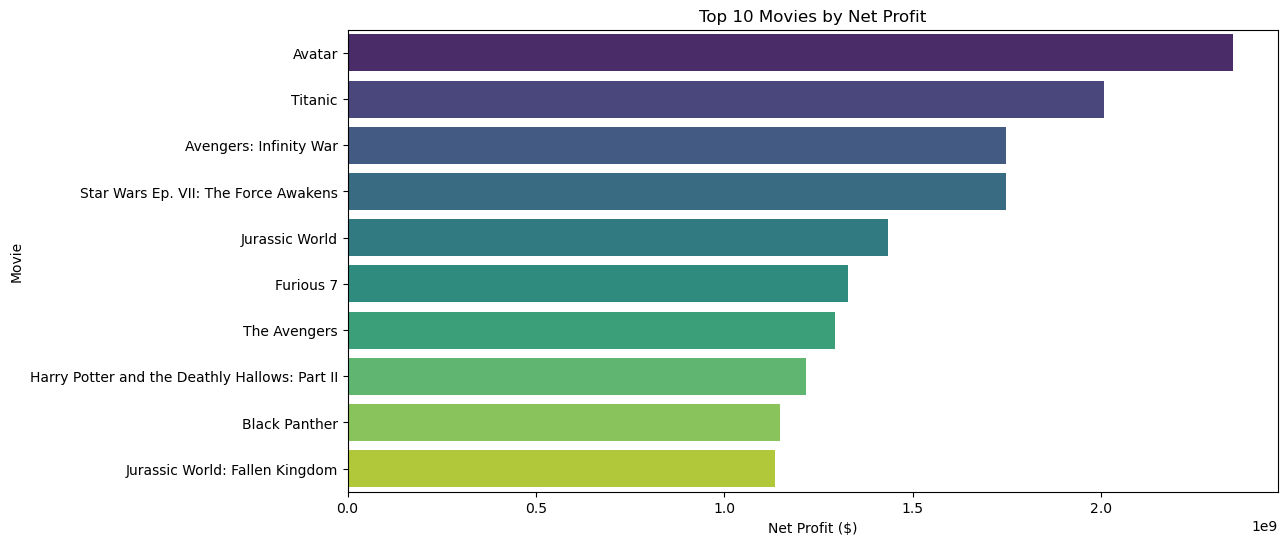

In [137]:
top10_movies = budget_numbers_df_copy.sort_values('net_profit', ascending=False).head(10)


plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_movies,
    x='net_profit',
    y='movie', 
    palette='viridis'
)

plt.title('Top 10 Movies by Net Profit')
plt.xlabel('Net Profit ($)')
plt.ylabel('Movie')

### Total Gross
   - the money a movie made worldwide, ie domestic + international
### Net Profit (or Loss)
   - production budget subtracted from the total gross
### Return on Investment
   - financial ratio that measures the profitability of an investment by comparing its gain or loss relative to its cost

   - represents efficiency; a movie can have the greatest ROI but not necessarily the most profit
   
(eg. returning a profit of 1,000 from an investment of 10 vs a profit of 10,000 from an investment of 5,000)

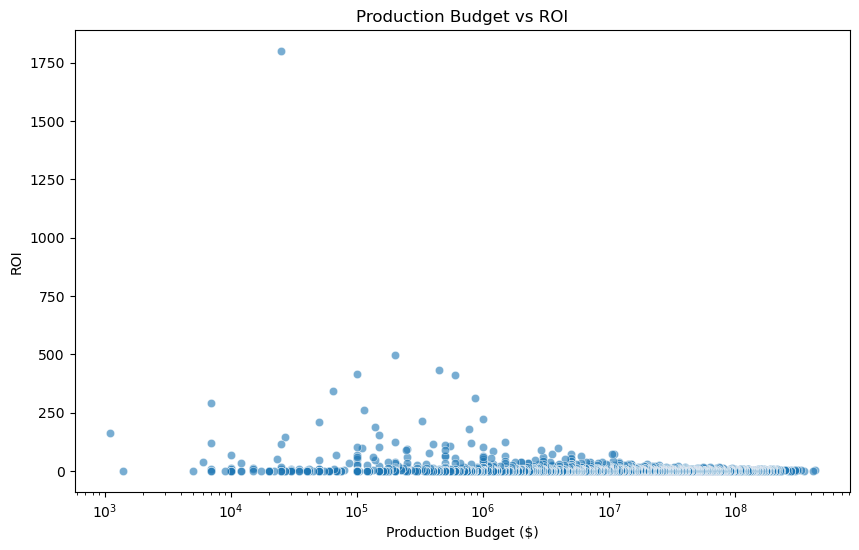

In [138]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=budget_numbers_df_copy,
    x='production_budget',
    y='ROI',
    alpha= 0.6,
)

plt.title('Production Budget vs ROI')
plt.xlabel('Production Budget ($)')
plt.ylabel('ROI')
plt.xscale('log')

In [139]:
budget_numbers_df_copy['release_date'] = pd.to_datetime(
    budget_numbers_df_copy['release_date'], errors='coerce'
)

budget_numbers_df_copy['release_year'] = budget_numbers_df_copy['release_date'].dt.year
budget_numbers_df_clean = budget_numbers_df_copy.dropna(subset=['release_year'])

budget_numbers_df_clean['release_year'] = budget_numbers_df_clean['release_year'].astype(int)


In [140]:
top_profit_per_year = (
    budget_numbers_df_clean.groupby('release_year')['net_profit']
    .max()
    .reset_index()
)

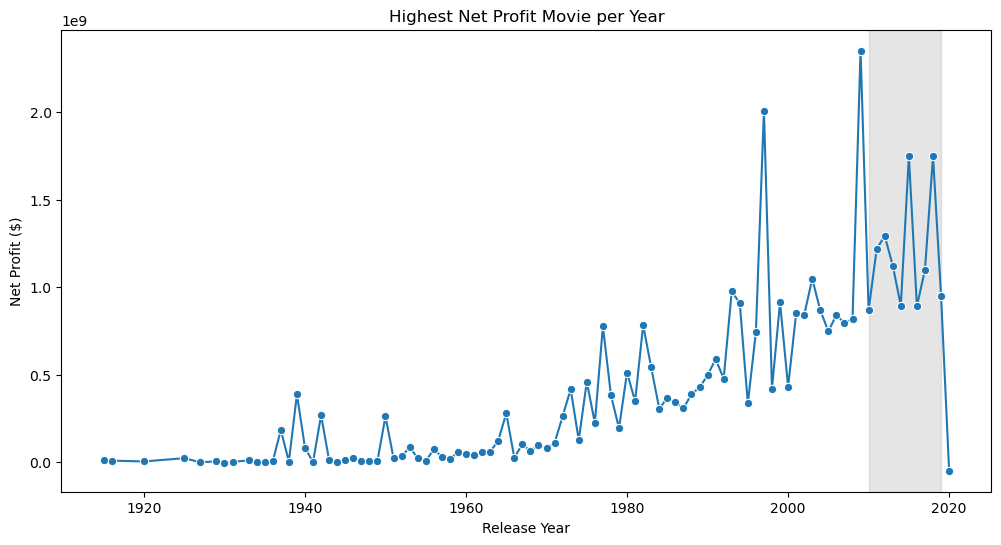

In [141]:

# line plot
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_profit_per_year,
    x='release_year',
    y='net_profit',
    marker='o'
)

plt.title('Highest Net Profit Movie per Year')
plt.xlabel('Release Year')
plt.ylabel('Net Profit ($)')
plt.axvspan(2010, 2019, color='gray', alpha=0.2, label='2010s')


## Insight: Profit vs ROI
Although superhero movies dominate total profit, they do not dominate ROI. 
This suggests that large studios benefit from scale, while smaller studios achieve efficiency with low-budget genre films.

* _17 movies made profits >$1,000,000,000_

* _6 of the 20 most profitable films were superhero movies_

* _17 of the 20 most profitable movies were from the 2010s_

* _28 movies had an ROI > 100; none of them superhero movies & most with a production budget <$1,000,000_

* _Only 2 of 30 movies with the highest ROI were from the 2010s_

# **Second dataset** ⬇️

This provides review/rating info

In [142]:
# make a connection
conn = sqlite3.connect('../Data/im.db')

# create a cursor object
cur = conn.cursor()

In [143]:
pd.read_sql("""

SELECT name AS Table_Names
FROM sqlite_master
WHERE type = 'table'
            
""", conn)

,Table_Names
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [144]:
imdb_movies = pd.read_sql("""
            
SELECT *
FROM movie_basics
            
""", conn)

In [145]:
imdb_ratings = pd.read_sql("""
            
SELECT *
FROM movie_ratings
            
""", conn)

In [146]:
maxprofit_ratings = pd.read_sql("""

SELECT *
FROM movie_basics AS mb
JOIN movie_ratings AS mr
  ON mb.movie_id = mr.movie_id
WHERE (mb.primary_title = 'Beauty and the Beast' AND mb.start_year = 2017)
   OR (mb.primary_title = 'Frozen' AND mb.start_year = 2013)
   OR mb.primary_title IN (
    'The Fate of the Furious',
    'Furious 7',
    'Aquaman',
    'Iron Man 3',
    'Incredibles 2',
    'Minions',
    'Black Panther',
    'Avengers: Age of Ultron',
    'Avengers: Infinity War',
    'The Avengers',
    'Jurassic World: Fallen Kingdom',
    'Jurassic World'
)
ORDER BY mr.averagerating DESC

""", conn)

maxprofit_ratings


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,movie_id,averagerating,numvotes
0,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi",tt4154756,8.5,670926
1,tt0848228,The Avengers,The Avengers,2012,143.0,"Action,Adventure,Sci-Fi",tt0848228,8.1,1183655
2,tt3606756,Incredibles 2,Incredibles 2,2018,118.0,"Action,Adventure,Animation",tt3606756,7.7,203510
3,tt2294629,Frozen,Frozen,2013,102.0,"Adventure,Animation,Comedy",tt2294629,7.5,516998
4,tt1825683,Black Panther,Black Panther,2018,134.0,"Action,Adventure,Sci-Fi",tt1825683,7.3,516148
5,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi",tt2395427,7.3,665594
6,tt1300854,Iron Man 3,Iron Man Three,2013,130.0,"Action,Adventure,Sci-Fi",tt1300854,7.2,692794
7,tt2771200,Beauty and the Beast,Beauty and the Beast,2017,129.0,"Family,Fantasy,Musical",tt2771200,7.2,238325
8,tt2820852,Furious 7,Furious Seven,2015,137.0,"Action,Crime,Thriller",tt2820852,7.2,335074
9,tt1477834,Aquaman,Aquaman,2018,143.0,"Action,Adventure,Fantasy",tt1477834,7.1,263328


In [147]:
maxprofit_ratings['genres'].value_counts()

Action,Adventure,Sci-Fi       7
Adventure,Animation,Comedy    2
Action,Crime,Thriller         2
Action,Adventure,Animation    1
Family,Fantasy,Musical        1
Action,Adventure,Fantasy      1
Name: genres, dtype: int64

In [148]:
def clean_title(title):
    return (
        str(title)
        .lower()                # lowercase
        .replace(':', '')       # remove punctuation
        .replace('–', '-')      # standardize dashes
        .replace('!', '')
        .strip()
    )


In [149]:
budget_numbers_df_copy['clean_movie'] = budget_numbers_df_copy['movie'].apply(clean_title)
imdb_movies['clean_title'] = imdb_movies['primary_title'].apply(clean_title)

movies_merged = pd.merge(
    budget_numbers_df_copy,
    imdb_movies[['clean_title', 'start_year', 'genres']],
    left_on=['clean_movie', 'release_year'],
    right_on=['clean_title', 'start_year'],
    how='left'
)


In [150]:
movies_merged['primary_genre'] = movies_merged['genres'].fillna('Unknown').str.split(',').str[0]

# Filter out movies where primary_genre is 'Unknown'
movies_with_genre = movies_merged[movies_merged['primary_genre'] != 'Unknown']


primary_genre_summary = (
    movies_with_genre
    .groupby('primary_genre')[['net_profit', 'ROI']]
    .median()
    .sort_values('net_profit', ascending=False))


top_genres = primary_genre_summary.head(10).index
top_genre_summary = primary_genre_summary.loc[top_genres]

In [151]:
movies_merged['primary_genre'].isnull().sum()

0

Text(0, 0.5, 'Primary Genre')

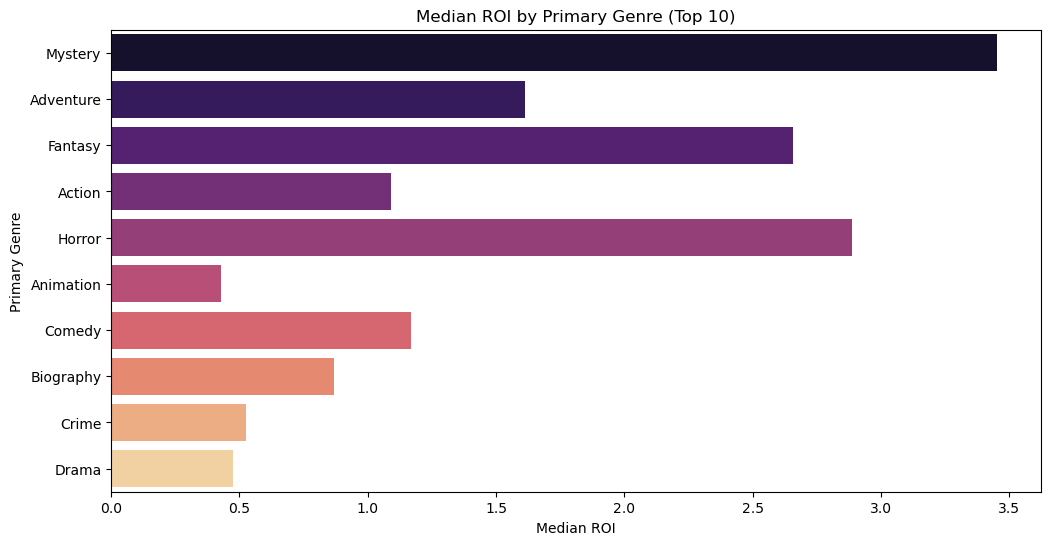

In [152]:

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_genre_summary.reset_index(),
    x='ROI',
    y='primary_genre',
    palette='magma'
)
plt.title('Median ROI by Primary Genre (Top 10)')
plt.xlabel('Median ROI')
plt.ylabel('Primary Genre')

Using the first listed genre as 'pry genre' provides a consistent (though imperfect) proxy for a movie’s primary marketing category and reduces the messiness of having to deal w >300 genres

Using median values to reduce the influence of extreme outliers common in movie revenue data

## Insight: Genre & Ratings

* _The tables from the imdb dataset do not have revenue data_

* _The only significant metric is ratings_

* _Of the 14 most profitable movies that appear on the imdb database, the average rating ranges from 8.5 to 6.2 for Avengers: Infinity War & Jurassic World: Fallen Kingdom respectively_

* _8.5 doesn't make the top 3,600 and 6.2 doesn't make the top 40,000 in terms of IMDb ratings. In other words even highly profitable films fall far outside the top tier of IMDb ratings_

* _Clearly critical acclaim is not a prerequisite for box office success_

* _The most common primary genre among high-profit films is Action_

* _Mystery & Horror have the highest median ROI_

# **Third dataset** ⬇️

This provides box office figures

In [153]:
boxoffice_df = pd.read_csv("../Data/bom.movie_gross.csv.gz")
boxoffice_df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


## Analysis & cleaning (bom gross)

In [154]:
boxoffice_df.isnull().sum()


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [155]:
boxoffice_df.dtypes


title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [156]:
boxoffice_df_copy = boxoffice_df.copy()

# Convert column to numeric
boxoffice_df_copy['foreign_gross'] = pd.to_numeric(boxoffice_df_copy['foreign_gross'], errors='coerce')


In [157]:
# total gross
boxoffice_df_copy['total_gross'] = boxoffice_df_copy['domestic_gross'] + boxoffice_df_copy['foreign_gross']

boxoffice_df_copy.sort_values('total_gross', ascending=False)

,title,studio,domestic_gross,foreign_gross,year,total_gross
727,Marvel's The Avengers,BV,623400000.0,895500000.0,2012,1.518900e+09
1875,Avengers: Age of Ultron,BV,459000000.0,946400000.0,2015,1.405400e+09
3080,Black Panther,BV,700100000.0,646900000.0,2018,1.347000e+09
328,Harry Potter and the Deathly Hallows Part 2,WB,381000000.0,960500000.0,2011,1.341500e+09
2758,Star Wars: The Last Jedi,BV,620200000.0,712400000.0,2017,1.332600e+09
...,...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018,NaN
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018,NaN
3384,El Pacto,Sony,2500.0,NaN,2018,NaN
3385,The Swan,Synergetic,2400.0,NaN,2018,NaN


In [158]:
studio_gross = (
    boxoffice_df_copy
    .groupby('studio')['total_gross']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_studios = studio_gross.head(10)


Text(0, 0.5, 'Studio')

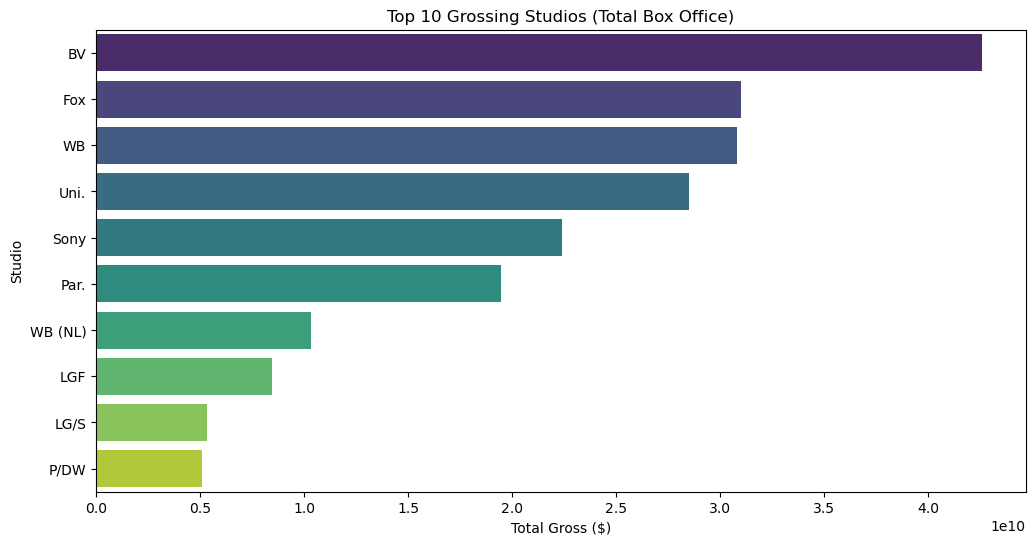

In [159]:

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_studios,
    x='total_gross',
    y='studio',
    palette='viridis'
)

plt.title('Top 10 Grossing Studios (Total Box Office)')
plt.xlabel('Total Gross ($)')
plt.ylabel('Studio')


## Insight

* _The top 3 highest-grossing films (total gross) are all superhero movies_

* _7 of the top 20 are superhero movies_

* _4 of the 20 are animated movies_

* _12 of the top 20 films are from the same studio - BV_

* _Buena Vista (Disney) dominates box office revenue, reflecting the advantage of established franchises_

* _The box office database doesn't reveal profitability or ROI bc there's no column for production budget_

## Business Recommendations

1. Large studio: Invest in mid-to-high budget franchise films (/popular IP like Harry Potter) to maximize net profit

2. Smaller studio: Invest in low-budget genre films (mystery, horror) to maximize ROI and reduce downside risk

3. Marketing: for low-budget genre films, focus on cost-efficient marketing like social media campaigns. while for high-budget franchise films, invest heavily in pre-release hype, cross-promotion (like videogame or toy partnerships) and global campaigns to maximize gross revenue

## Data Limitations
- IMDb lacks revenue data, limiting profitability analysis
- Genre labeling is messy & inconsistent across IMDb
- BOM lacks production budgets, preventing ROI calculations
- Matching movie titles across datasets may introduce errors
- ROI is calculated using production budget only, as marketing costs are not available in the dataset